In [ ]:
import pandas as pd
import os

def load_csv_from_folder(folder_path):
    csv_files = []
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))
    
    df_list = []
    for file in csv_files:
        df = pd.read_csv(file)
        df_list.append(df)
    
    combined_df = pd.concat(df_list, ignore_index=True)
    
    return combined_df

folder_path = '/home/lorenzo/data/Videos'
combined_df = load_csv_from_folder(folder_path)

# print(combined_df['weather_prediction'].describe())
# print("\n")
print(combined_df['weather_prediction'].value_counts())
print("\n")

# snow_samples = combined_df[combined_df['weather_prediction'] == 'snow'].sample(5)
# for index, row in snow_samples.iterrows():
#     print(f"Video Path: {row['video_path']}\nFrame Number: {row['frame_number']}\nWeather: {row['weather_prediction']}\n")

print("Snow predictions by directory:")
print(combined_df[combined_df['weather_prediction'] == 'snow']['video_path'].apply(lambda x: os.path.dirname(x)).value_counts())
print("\n")

print("Hail predictions by directory:")
print(combined_df[combined_df['weather_prediction'] == 'hail']['video_path'].apply(lambda x: os.path.dirname(x)).value_counts())

weather_prediction
overcast    1145348
sunshine     158949
snow          42760
hail            252
Name: count, dtype: int64


Snow predictions by directory:
video_path
/home/lorenzo/data/Videos/2023/Calanda/Scabiosa      21513
/home/lorenzo/data/Videos/2023/Helgaset/Trifolium    14606
/home/lorenzo/data/Videos/2023/Helgaset/Succisa       6641
Name: count, dtype: int64


Hail predictions by directory:
video_path
/home/lorenzo/data/Videos/2023/Helgaset/Succisa      214
/home/lorenzo/data/Videos/2023/Helgaset/Trifolium     27
/home/lorenzo/data/Videos/2023/Calanda/Scabiosa       11
Name: count, dtype: int64


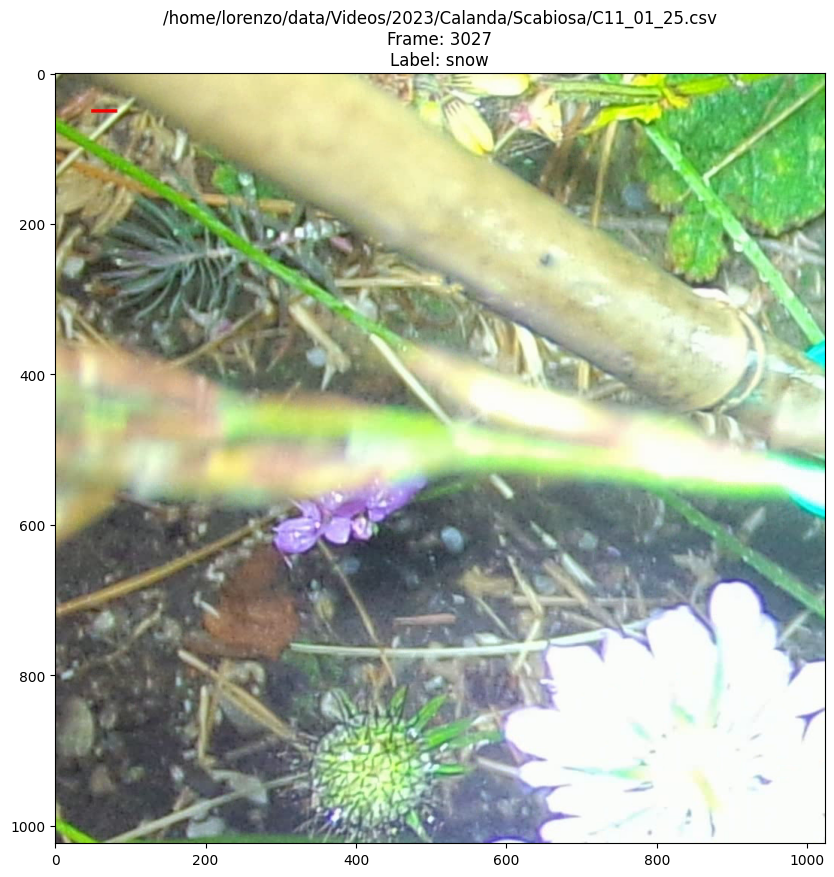

In [ ]:
import os
import random
import pandas as pd
import cv2
from matplotlib import pyplot as plt

def load_frame_label(folder, csv_path=None, frame=None):

    csv_files = []
    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))

    if len(csv_files) == 0:
        print("No csv files found in the specified folder.")
        return None, None
    
    if csv_path is not None:
        if csv_path in csv_files:
            csv_file = csv_path
            if frame is None:
                df = pd.read_csv(csv_file)
                frame = random.choice(df['frame_number'].unique())
        else:
            return None, None
    else:
        csv_file = random.choice(csv_files)
        df = pd.read_csv(csv_file)
        if frame is None:
            frame = random.choice(df['frame_number'].unique())
        elif frame not in df['frame_number'].values:
            return None, None

    df = pd.read_csv(csv_file)
    row = df[df['frame_number'] == frame].iloc[0]

    video_path = csv_file.replace('.csv', '.mp4')
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame)
    ret, image = cap.read()
    cap.release()
    label = row['weather_prediction']

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"{csv_file}\nFrame: {frame}\nLabel: {label}")
    plt.show()

    return image, label

folder = '/home/lorenzo/data/Videos'

image, label = load_frame_label(folder, csv_path="/home/lorenzo/data/Videos/2023/Calanda/Scabiosa/C04_01_6.csv", frame=5374)
image, label = load_frame_label(folder, csv_path="/home/lorenzo/data/Videos/2023/Calanda/Scabiosa/C11_01_25.csv", frame=3027)
image, label = load_frame_label(folder, csv_path="/home/lorenzo/data/Videos/2023/Calanda/Scabiosa/C05_01_9.csv", frame=3838)

if image is None and label is None:
    print("No image and label found.")